# Why combining state equations changes `solve_ivp` behavior

This notebook shows a small example of why two models can look different when they are solved separately versus when their state equations are combined and passed to `solve_ivp`.

Main idea: `solve_ivp` uses adaptive time steps. When two systems are solved together, the solver chooses time steps that satisfy the error tolerance for the whole combined state vector, not only one variable.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True

## 1. Two simple independent models

Model 1 changes slowly:

$$\frac{dx}{dt} = -x$$

Model 2 changes quickly:

$$\frac{dy}{dt} = -100y$$

Mathematically, if they are independent, solving them separately or together gives the same physical solution. But the solver time points can be very different.

In [2]:
def slow_model(t, x):
    return [-x[0]]


def fast_model(t, y):
    return [-100 * y[0]]


def combined_independent_model(t, z):
    x, y = z
    dxdt = -x
    dydt = -100 * y
    return [dxdt, dydt]


t_span = (0, 2)
x0 = [1.0]
y0 = [1.0]
z0 = [1.0, 1.0]

sol_slow = solve_ivp(slow_model, t_span, x0)
sol_fast = solve_ivp(fast_model, t_span, y0)
sol_combined = solve_ivp(combined_independent_model, t_span, z0)

print(f"slow model:     {len(sol_slow.t):3d} returned time points, nfev = {sol_slow.nfev}")
print(f"fast model:     {len(sol_fast.t):3d} returned time points, nfev = {sol_fast.nfev}")
print(f"combined model: {len(sol_combined.t):3d} returned time points, nfev = {sol_combined.nfev}")

slow model:       5 returned time points, nfev = 26
fast model:      71 returned time points, nfev = 458
combined model:  70 returned time points, nfev = 488


The combined model usually returns time points more like the fast model, because the fast state `y` forces the adaptive solver to take smaller steps.

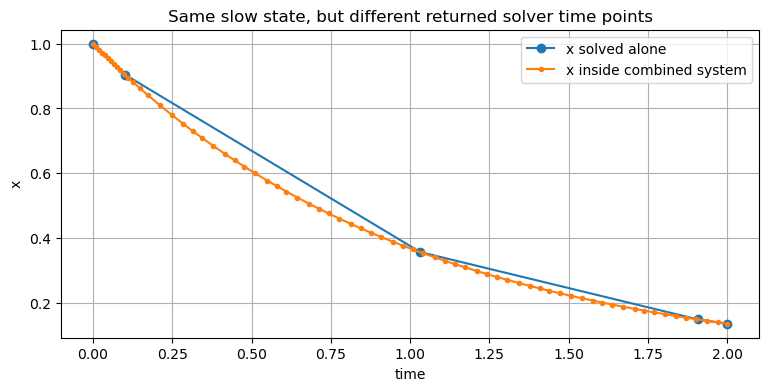

In [3]:
plt.plot(sol_slow.t, sol_slow.y[0], "o-", label="x solved alone")
plt.plot(sol_combined.t, sol_combined.y[0], ".-", label="x inside combined system")
plt.xlabel("time")
plt.ylabel("x")
plt.title("Same slow state, but different returned solver time points")
plt.legend();

## 2. Compare at the same requested times with `t_eval`

If you compare `sol.t` directly, you may be comparing different time grids. Use `t_eval` when you want results returned at the same times.

Same returned time grid: True
Maximum difference in x: 4.586e-04


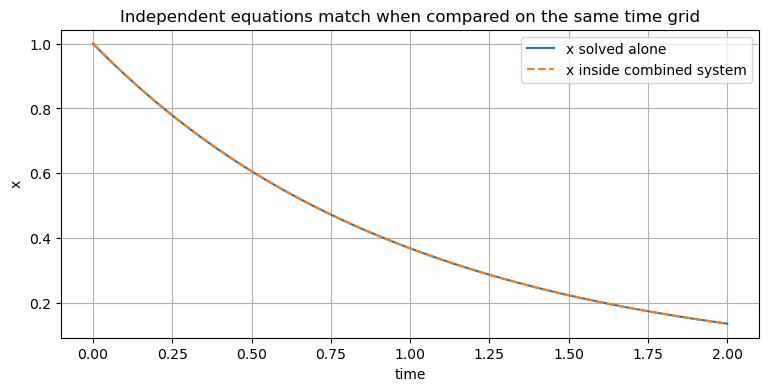

In [4]:
t_eval = np.linspace(0, 2, 300)

sol_slow_eval = solve_ivp(slow_model, t_span, x0, t_eval=t_eval)
sol_combined_eval = solve_ivp(combined_independent_model, t_span, z0, t_eval=t_eval)

x_alone = sol_slow_eval.y[0]
x_combined = sol_combined_eval.y[0]
max_difference = np.max(np.abs(x_alone - x_combined))

print(f"Same returned time grid: {np.allclose(sol_slow_eval.t, sol_combined_eval.t)}")
print(f"Maximum difference in x: {max_difference:.3e}")

plt.plot(t_eval, x_alone, label="x solved alone")
plt.plot(t_eval, x_combined, "--", label="x inside combined system")
plt.xlabel("time")
plt.ylabel("x")
plt.title("Independent equations match when compared on the same time grid")
plt.legend();

The two `x` curves should almost overlap. Any small difference is numerical tolerance, not different physics.

However, `t_eval` only controls the times returned to you. Internally, `solve_ivp` can still take different adaptive steps.

## 3. A real solution change happens if the equations become coupled

If the combined model accidentally or intentionally makes one state depend on the other, then the solution is no longer the same model.

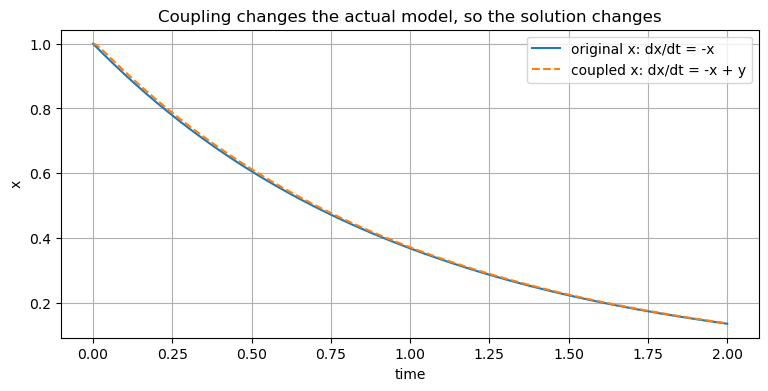

In [5]:
def combined_coupled_model(t, z):
    x, y = z
    dxdt = -x + y       # x is now affected by y
    dydt = -100 * y
    return [dxdt, dydt]


sol_coupled_eval = solve_ivp(combined_coupled_model, t_span, z0, t_eval=t_eval)

plt.plot(t_eval, x_alone, label="original x: dx/dt = -x")
plt.plot(t_eval, sol_coupled_eval.y[0], "--", label="coupled x: dx/dt = -x + y")
plt.xlabel("time")
plt.ylabel("x")
plt.title("Coupling changes the actual model, so the solution changes")
plt.legend();

## 4. Checklist for your PEMFC combined model

When a combined state equation gives a different result, check these points:

1. Are the states in the same order everywhere? Example: `[p_O2, p_H2, T]` must be unpacked in exactly that order.
2. Are the initial conditions correct for the combined state vector?
3. Did you accidentally add coupling between two models?
4. Are some states much faster than others? This changes adaptive solver steps.
5. Are some states much larger or smaller in magnitude? Then `atol` and `rtol` matter a lot.
6. Are you comparing different returned time arrays? Use `t_eval` for fair comparison.
7. Is the combined system stiff? Try `method="BDF"` or `method="Radau"` if RK45 becomes slow or unstable.

In [6]:
# Example of using stricter tolerances and a fixed output grid.
# This is often useful when debugging combined dynamic models.

sol_debug = solve_ivp(
    combined_independent_model,
    t_span,
    z0,
    t_eval=t_eval,
    rtol=1e-8,
    atol=1e-10,
)

print(sol_debug.message)
print(f"nfev = {sol_debug.nfev}")

The solver successfully reached the end of the integration interval.
nfev = 950
